In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [ ]:
# 1

import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Load + normalize + one-hot encode + split (all in one flow)
(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()

X_train_full, X_test = X_train_full.astype("float32")/255.0, X_test.astype("float32")/255.0
y_train_full, y_test = to_categorical(y_train_full, 10), to_categorical(y_test, 10)

X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

# Output shapes
print(f"Train: {X_train.shape}, {y_train.shape}")
print(f"Val:   {X_val.shape}, {y_val.shape}")
print(f"Test:  {X_test.shape}, {y_test.shape}")

Train: (48000, 28, 28), (48000, 10)
Val:   (12000, 28, 28), (12000, 10)
Test:  (10000, 28, 28), (10000, 10)


Accuracy: 0.9169


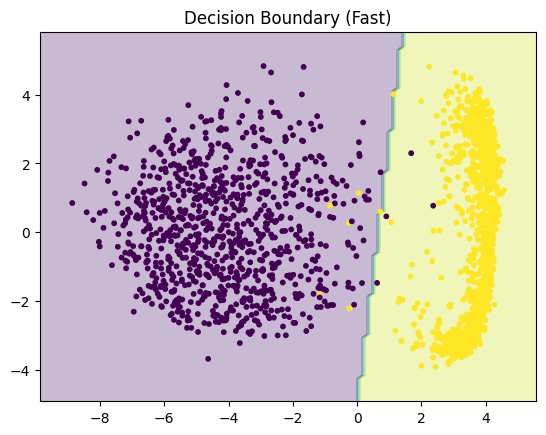

In [ ]:
# 2

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

# Load only training set (enough)
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Use SMALL subset for speed
X_train = X_train[:20000]
y_train = y_train[:20000]

# Normalize + flatten
X_train = X_train.astype("float32")/255.0
X_test  = X_test.astype("float32")/255.0

X_train = X_train.reshape(len(X_train), -1)
X_test  = X_test.reshape(len(X_test), -1)

# Train FAST model
model = LogisticRegression(max_iter=200, solver='lbfgs')  # faster than saga
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

# ---- PCA (only small subset) ----
mask = (y_train == 0) | (y_train == 1)
X_bin = X_train[mask][:2000]   # reduce size
y_bin = y_train[mask][:2000]

X_pca = PCA(n_components=2).fit_transform(X_bin)

clf = LogisticRegression().fit(X_pca, y_bin)

# Smaller grid
xx, yy = np.meshgrid(
    np.linspace(X_pca[:,0].min()-1, X_pca[:,0].max()+1, 100),
    np.linspace(X_pca[:,1].min()-1, X_pca[:,1].max()+1, 100)
)

Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_bin, s=10)
plt.title("Decision Boundary (Fast)")
plt.show()

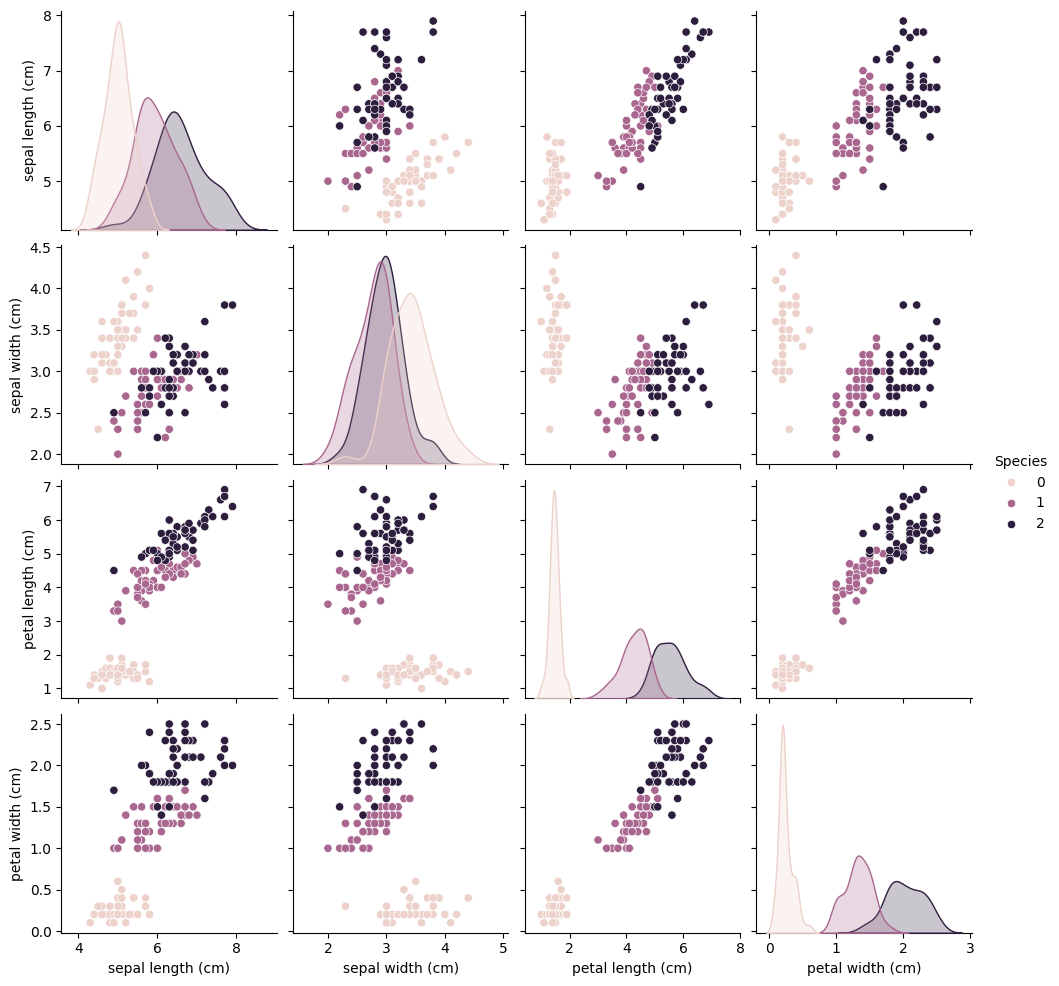

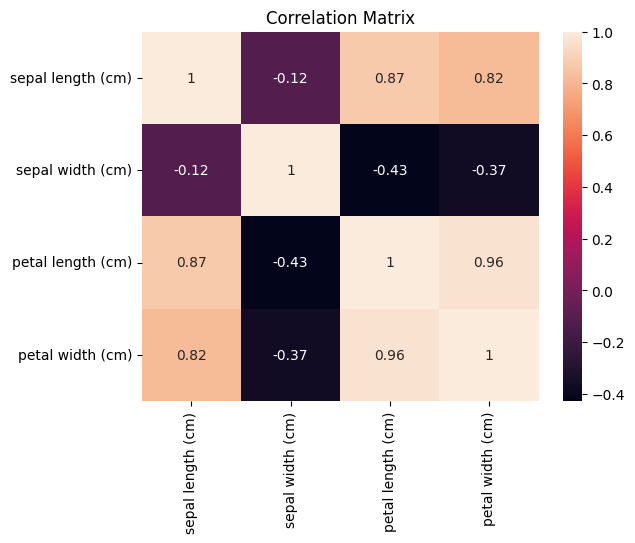

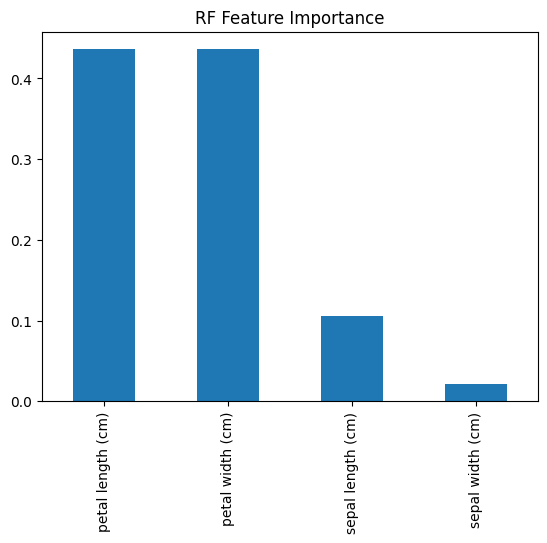

Univariate: ['petal length (cm)', 'petal width (cm)']
RFE: ['petal length (cm)', 'petal width (cm)']
Accuracy (All): 1.0
Accuracy (Selected): 1.0


In [ ]:
# 4 One-cell Iris Feature Selection + Classification (clean version)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load data
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# --- Visualization ---
sns.pairplot(pd.concat([X, pd.Series(y, name="Species")], axis=1), hue="Species")
plt.show()

sns.heatmap(X.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

# --- Feature Selection ---
# 1. Univariate
uni_selector = SelectKBest(f_classif, k=2)
X_uni = uni_selector.fit_transform(X, y)
uni_features = X.columns[uni_selector.get_support()]

# 2. Random Forest Importance
rf = RandomForestClassifier(random_state=42).fit(X, y)
rf_importance = pd.Series(rf.feature_importances_, index=X.columns)
rf_importance.sort_values(ascending=False).plot(kind='bar')
plt.title("RF Feature Importance")
plt.show()

# 3. RFE
rfe = RFE(SVC(kernel='linear'), n_features_to_select=2)
X_rfe = rfe.fit_transform(X, y)
rfe_features = X.columns[rfe.support_]

print("Univariate:", list(uni_features))
print("RFE:", list(rfe_features))

# --- Model Training ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Full features
model_full = SVC().fit(X_train, y_train)
acc_full = accuracy_score(y_test, model_full.predict(X_test))

# Selected features
X_train_rfe, X_test_rfe, _, _ = train_test_split(X[rfe_features], y, test_size=0.2, random_state=42)
model_rfe = SVC().fit(X_train_rfe, y_train)
acc_rfe = accuracy_score(y_test, model_rfe.predict(X_test_rfe))

print("Accuracy (All):", acc_full)
print("Accuracy (Selected):", acc_rfe)

In [ ]:
# 5 One-cell Apriori (Association Rule Mining - clean version)

import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# Sample transactions
transactions = [
    ['milk', 'bread', 'butter'],
    ['bread', 'butter'],
    ['milk', 'bread'],
    ['milk', 'butter'],
    ['bread', 'butter', 'jam'],
    ['milk', 'bread', 'butter', 'jam'],
    ['bread'],
    ['milk', 'bread', 'butter'],
    ['milk', 'jam'],
    ['bread', 'butter']
]

# Encode transactions
te = TransactionEncoder()
df = pd.DataFrame(te.fit(transactions).transform(transactions), columns=te.columns_)

# Apriori: frequent itemsets
freq_items = apriori(df, min_support=0.3, use_colnames=True)

# Association rules
rules = association_rules(freq_items, metric="confidence", min_threshold=0.6)

# Strong rules
strong_rules = rules[(rules['confidence'] > 0.7) & (rules['lift'] > 1)]

# Output
print("Frequent Itemsets:\n", freq_items)
print("\nAll Rules:\n", rules[['antecedents','consequents','support','confidence','lift']])
print("\nStrong Rules:\n", strong_rules[['antecedents','consequents','support','confidence','lift']])

Frequent Itemsets:
    support               itemsets
0      0.8                (bread)
1      0.7               (butter)
2      0.3                  (jam)
3      0.6                 (milk)
4      0.6        (bread, butter)
5      0.4          (milk, bread)
6      0.4         (milk, butter)
7      0.3  (milk, bread, butter)

All Rules:
       antecedents consequents  support  confidence      lift
0         (bread)    (butter)      0.6    0.750000  1.071429
1        (butter)     (bread)      0.6    0.857143  1.071429
2          (milk)     (bread)      0.4    0.666667  0.833333
3          (milk)    (butter)      0.4    0.666667  0.952381
4   (milk, bread)    (butter)      0.3    0.750000  1.071429
5  (milk, butter)     (bread)      0.3    0.750000  0.937500

Strong Rules:
      antecedents consequents  support  confidence      lift
0        (bread)    (butter)      0.6    0.750000  1.071429
1       (butter)     (bread)      0.6    0.857143  1.071429
4  (milk, bread)    (butter)      0.3 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# 6 ONE-CELL RECOMMENDER SYSTEM (USER + ITEM + HYBRID)

import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import precision_score, recall_score, f1_score

# -------- DATA --------
ratings = pd.DataFrame({
    "Movie1":[5,4,0,0,1],
    "Movie2":[4,0,0,2,1],
    "Movie3":[0,0,5,4,0],
    "Movie4":[0,3,4,0,0],
    "Movie5":[1,0,4,5,0]
}, index=["User1","User2","User3","User4","User5"])

print("Ratings:\n", ratings)

# -------- SIMILARITY --------
user_sim = pd.DataFrame(cosine_similarity(ratings), index=ratings.index, columns=ratings.index)
item_sim = pd.DataFrame(cosine_similarity(ratings.T), index=ratings.columns, columns=ratings.columns)

# -------- USER-BASED --------
def user_rec(user):
    sim = user_sim[user].drop(user)
    scores = sum(sim[u] * ratings.loc[u] for u in sim.index)
    scores[ratings.loc[user] > 0] = 0
    return scores

# -------- ITEM-BASED --------
def item_rec(user):
    user_r = ratings.loc[user]
    scores = sum(item_sim[m] * user_r[m] for m in ratings.columns if user_r[m] > 0)
    scores[user_r > 0] = 0
    return scores

# -------- HYBRID --------
def hybrid(user, alpha=0.5):
    return (alpha * user_rec(user) + (1-alpha) * item_rec(user)).fillna(0)

# -------- RESULTS --------
user = "User1"
rec = hybrid(user).sort_values(ascending=False)

print("\nRecommendations for", user, ":\n", rec.head(2))

# -------- EVALUATION --------
true = (ratings.loc[user] >= 4).astype(int)
pred = pd.Series(0, index=ratings.columns)
pred[rec.head(2).index] = 1

print("\nPrecision:", precision_score(true, pred))
print("Recall   :", recall_score(true, pred))
print("F1 Score :", f1_score(true, pred))

Ratings:
        Movie1  Movie2  Movie3  Movie4  Movie5
User1       5       4       0       0       1
User2       4       0       0       3       0
User3       0       0       5       4       4
User4       0       2       4       0       5
User5       1       1       0       0       0

Recommendations for User1 :
 Movie4    2.262029
Movie3    1.829678
dtype: float64

Precision: 0.0
Recall   : 0.0
F1 Score : 0.0


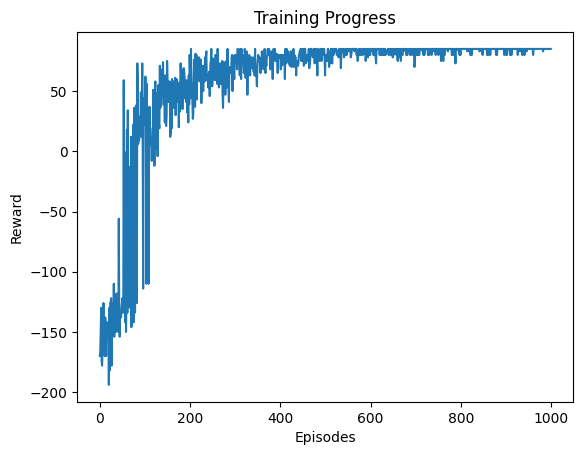

Path: [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 4), (2, 4), (2, 3), (2, 2), (2, 1), (2, 0), (3, 0), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4)]
Reached Goal!
Success Rate: 1.0


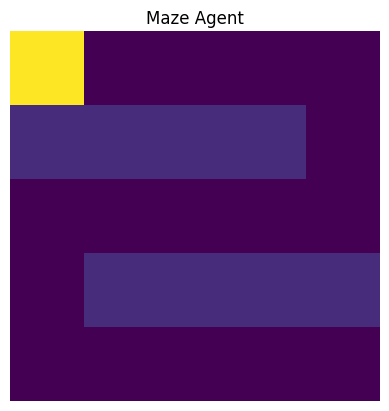

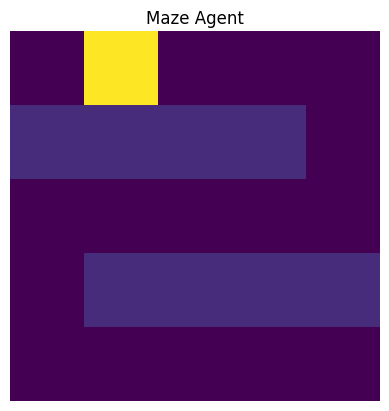

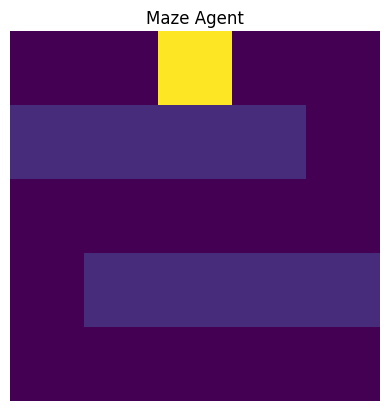

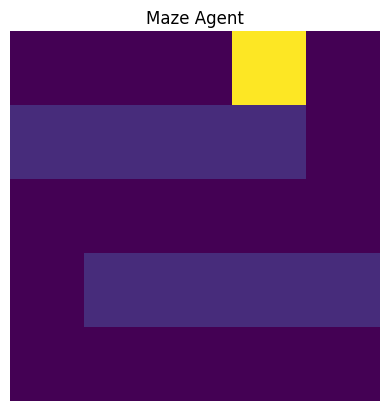

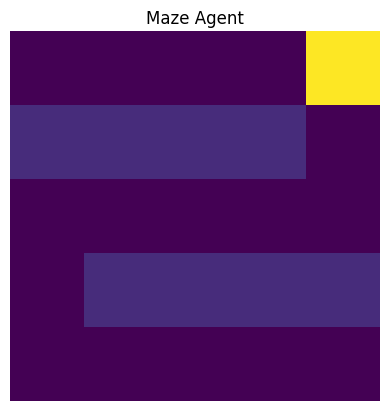

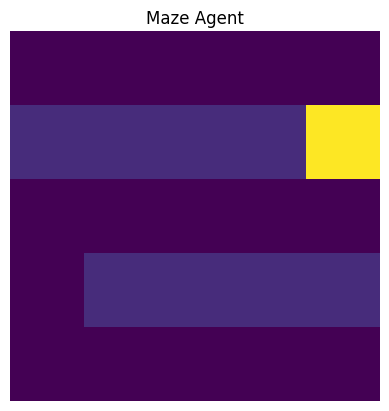

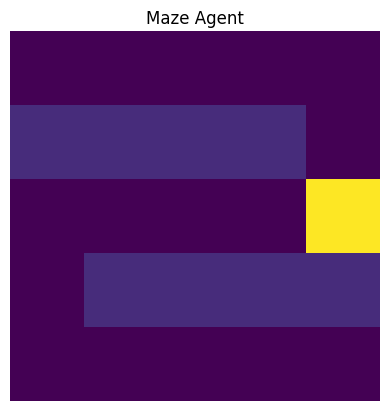

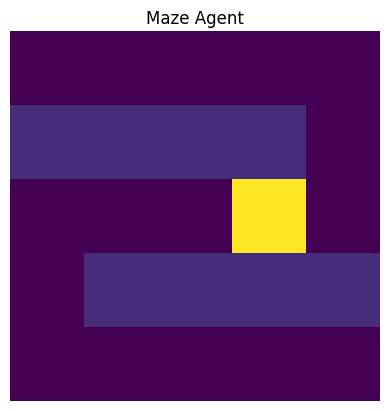

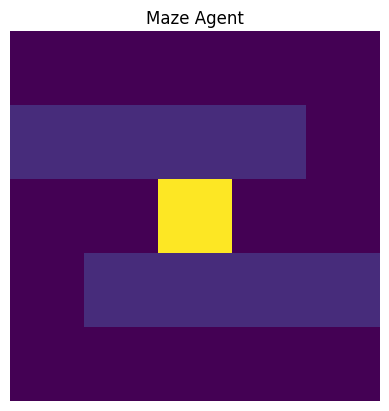

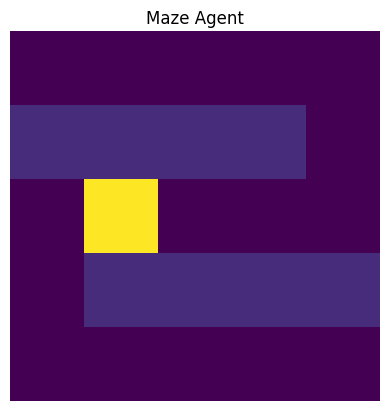

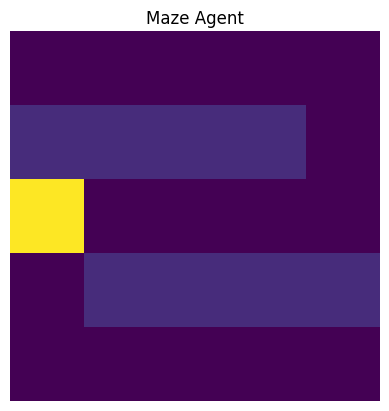

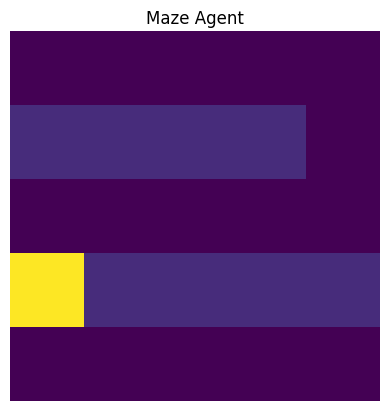

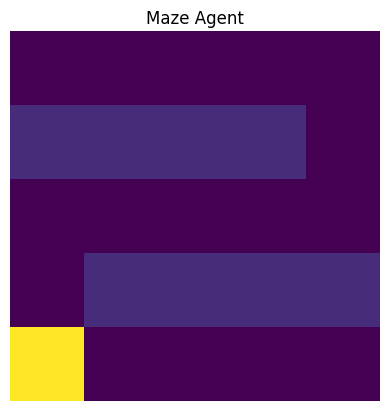

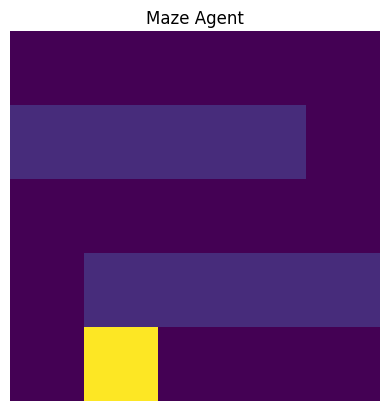

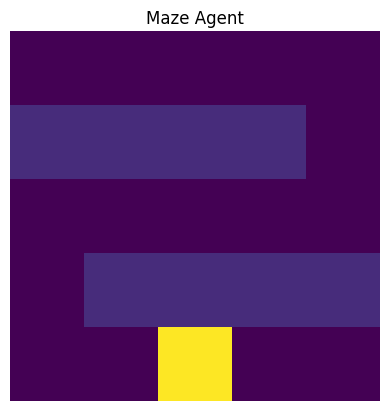

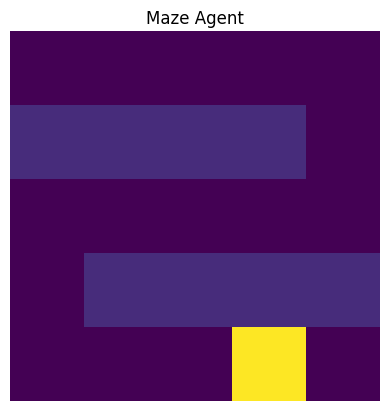

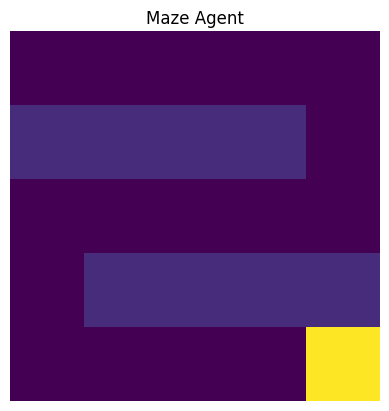

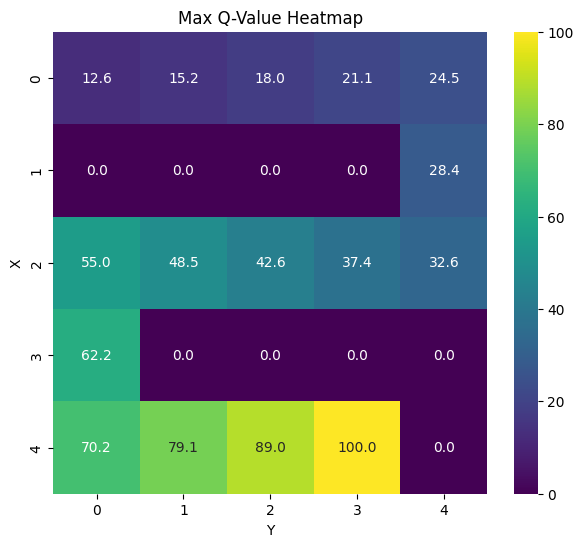

In [ ]:
# 7 ONE-CELL COMPLETE Q-LEARNING MAZE (CLEAN + FIXED)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gymnasium as gym
from gymnasium import spaces

# ----- Environment -----
class MazeEnv(gym.Env):
    def __init__(self):
        self.maze = np.array([
            [0,0,0,0,0],
            [1,1,1,1,0],
            [0,0,0,0,0],
            [0,1,1,1,1],
            [0,0,0,0,0]
        ])
        self.start, self.goal = (0,0), (4,4)
        self.state = self.start
        self.action_space = spaces.Discrete(4)

    def reset(self):
        self.state = self.start
        return self.state, {}

    def step(self, action):
        x, y = self.state
        moves = [(-1,0),(1,0),(0,-1),(0,1)]
        nx, ny = x + moves[action][0], y + moves[action][1]

        if not (0 <= nx < 5 and 0 <= ny < 5 and self.maze[nx, ny] == 0):
            return self.state, -5, False, False, {}

        self.state = (nx, ny)

        if self.state == self.goal:
            return self.state, 100, True, False, {}

        return self.state, -1, False, False, {}

    def render(self):
        grid = self.maze.copy()
        x, y = self.state
        grid[x, y] = 8
        plt.imshow(grid)
        plt.title("Maze Agent")
        plt.axis("off")
        plt.show()

# ----- Setup -----
env = MazeEnv()
q_table = {(x,y): np.zeros(4) for x in range(5) for y in range(5)}

alpha, gamma = 0.1, 0.9
epsilon, decay, min_eps = 1.0, 0.995, 0.01
episodes = 1000

rewards = []

# ----- Training -----
for _ in range(episodes):
    state, _ = env.reset()
    total = 0

    for _ in range(50):
        action = np.random.randint(4) if np.random.rand() < epsilon else np.argmax(q_table[state])
        next_state, reward, done, _, _ = env.step(action)

        q_table[state][action] += alpha * (
            reward + gamma * np.max(q_table[next_state]) - q_table[state][action]
        )

        state = next_state
        total += reward

        if done:
            break

    epsilon = max(min_eps, epsilon * decay)
    rewards.append(total)

# ----- Plot Training -----
plt.plot(rewards)
plt.title("Training Progress")
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.show()

# ----- Test Path -----
state, _ = env.reset()
path = [state]

for _ in range(50):
    action = np.argmax(q_table[state])
    state, _, done, _, _ = env.step(action)
    path.append(state)
    if done:
        break

print("Path:", path)
print("Reached Goal!" if state == env.goal else "Failed")

# ----- Success Rate -----
success = 0
for _ in range(50):
    state, _ = env.reset()
    for _ in range(50):
        state, _, done, _, _ = env.step(np.argmax(q_table[state]))
        if done:
            success += 1
            break

print("Success Rate:", success/50)

# ----- Render Path -----
state, _ = env.reset()
for _ in range(20):
    env.render()
    action = np.argmax(q_table[state])
    state, _, done, _, _ = env.step(action)
    if done:
        env.render()
        break

# ----- Q-Table Heatmap -----
max_q = np.zeros((5,5))
for (x,y), q_vals in q_table.items():
    max_q[x,y] = np.max(q_vals)

plt.figure(figsize=(7,6))
sns.heatmap(max_q, annot=True, cmap="viridis", fmt=".1f")
plt.title("Max Q-Value Heatmap")
plt.xlabel("Y")
plt.ylabel("X")
plt.show()

In [ ]:
// 8 SIMPLE OpenCV + OpenMP IMAGE PROCESSING

#include <iostream>
#include <opencv2/opencv.hpp>
#include <omp.h>

using namespace cv;
using namespace std;

// -------- Generic Convolution Function --------
void applyFilter(const Mat& input, Mat& output, float kernel[3][3]) {
    #pragma omp parallel for
    for (int i = 1; i < input.rows - 1; i++) {
        for (int j = 1; j < input.cols - 1; j++) {
            for (int c = 0; c < input.channels(); c++) {
                float sum = 0;
                for (int k = -1; k <= 1; k++)
                    for (int l = -1; l <= 1; l++)
                        sum += input.at<Vec3b>(i+k, j+l)[c] * kernel[k+1][l+1];

                output.at<Vec3b>(i, j)[c] = saturate_cast<uchar>(sum);
            }
        }
    }
}

int main() {

    // Load Image
    Mat image = imread("input.jpg");
    if (image.empty()) {
        cout << "Error loading image!" << endl;
        return -1;
    }

    cout << "Image Loaded\n";

    Mat blur_serial = image.clone(), blur_parallel = image.clone();
    Mat sharpen = image.clone(), gray, edges;

    // -------- Kernels --------
    float blur_kernel[3][3] = {
        {1/9.0,1/9.0,1/9.0},
        {1/9.0,1/9.0,1/9.0},
        {1/9.0,1/9.0,1/9.0}
    };

    float sharpen_kernel[3][3] = {
        {0,-1,0},
        {-1,5,-1},
        {0,-1,0}
    };

    // -------- SERIAL BLUR --------
    double start = omp_get_wtime();

    for (int i = 1; i < image.rows - 1; i++)
        for (int j = 1; j < image.cols - 1; j++)
            for (int c = 0; c < 3; c++) {
                float sum = 0;
                for (int k = -1; k <= 1; k++)
                    for (int l = -1; l <= 1; l++)
                        sum += image.at<Vec3b>(i+k,j+l)[c] * blur_kernel[k+1][l+1];

                blur_serial.at<Vec3b>(i,j)[c] = saturate_cast<uchar>(sum);
            }

    double serial_time = omp_get_wtime() - start;

    // -------- PARALLEL BLUR --------
    start = omp_get_wtime();
    applyFilter(image, blur_parallel, blur_kernel);
    double parallel_time = omp_get_wtime() - start;

    cout << "Serial Time: " << serial_time << endl;
    cout << "Parallel Time: " << parallel_time << endl;
    cout << "Speedup: " << serial_time/parallel_time << endl;

    // -------- SHARPEN --------
    applyFilter(image, sharpen, sharpen_kernel);
    cout << "Sharpen Done\n";

    // -------- EDGE DETECTION --------
    cvtColor(image, gray, COLOR_BGR2GRAY);
    edges = gray.clone();

    int sobel_x[3][3] = {
        {-1,0,1},
        {-2,0,2},
        {-1,0,1}
    };

    #pragma omp parallel for
    for (int i = 1; i < gray.rows - 1; i++) {
        for (int j = 1; j < gray.cols - 1; j++) {
            int gx = 0;

            for (int k = -1; k <= 1; k++)
                for (int l = -1; l <= 1; l++)
                    gx += gray.at<uchar>(i+k,j+l) * sobel_x[k+1][l+1];

            edges.at<uchar>(i,j) = saturate_cast<uchar>(abs(gx));
        }
    }

    cout << "Edge Detection Done\n";

    // -------- SAVE --------
    imwrite("blur_serial.jpg", blur_serial);
    imwrite("blur_parallel.jpg", blur_parallel);
    imwrite("sharpen.jpg", sharpen);
    imwrite("edges.jpg", edges);

    cout << "Saved all outputs\n";

    return 0;
}

In [ ]:
# 9 ONE-CELL DIMENSIONALITY REDUCTION COMPARISON (CLEAN)

import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.manifold import TSNE

# Load data
X, y = load_iris(return_X_y=True)
print("Original Shape:", X.shape)

# Evaluation function
def evaluate(X_new, name):
    score = cross_val_score(SVC(kernel='linear'), X_new, y, cv=5).mean()
    print(f"{name}: {score:.4f}")

# -------- 2D --------
evaluate(PCA(n_components=2).fit_transform(X), "PCA (2D)")
evaluate(LDA(n_components=2, solver='svd').fit_transform(X, y), "LDA (2D)") # Fixed: added n_components and solver
evaluate(TSNE(n_components=2, random_state=42).fit_transform(X), "t-SNE (2D)")
evaluate(TruncatedSVD(n_components=2).fit_transform(X), "SVD (2D)")

# -------- 3D --------
evaluate(PCA(n_components=3).fit_transform(X), "PCA (3D)")
evaluate(TSNE(n_components=3, random_state=42).fit_transform(X), "t-SNE (3D)")
evaluate(TruncatedSVD(n_components=3).fit_transform(X), "SVD (3D)")


Original Shape: (150, 4)
PCA (2D): 0.9667
LDA (2D): 0.9800
t-SNE (2D): 0.9800
SVD (2D): 0.9667
PCA (3D): 0.9667
t-SNE (3D): 0.9533
SVD (3D): 0.9667


In [ ]:
// 10. Write a program to print first n natural numbers using thread.
#include <iostream>
#include <thread>
using namespace std;

void printNumbers(int n)
{
    cout << "First " << n << " natural numbers are:\n";
    for(int i = 1; i <= n; i++)
    {cout << i << " ";}
    cout << endl;
}

int main()
{
    int n;
    cout << "Enter value of n: ";
    cin >> n;
    // Create thread
    thread t(printNumbers, n);
    // Wait for thread to finish
    t.join();

    return 0;
}

In [ ]:
//11 SIMPLE MULTITHREADING: SUM + SEARCH

#include <iostream>
#include <vector>
#include <thread>
#include <chrono>
#include <cstdlib>

using namespace std;
using namespace chrono;

// -------- Worker Functions --------
void partialSum(const vector<int>& arr, int s, int e, long long& res) {
    res = 0;
    for (int i = s; i < e; i++) res += arr[i];
}

void partialSearch(const vector<int>& arr, int s, int e, int key, bool& found) {
    for (int i = s; i < e; i++)
        if (arr[i] == key) { found = true; return; }
}

int main() {

    int n, key;
    cout << "Enter size & key: ";
    cin >> n >> key;

    // Generate data
    vector<int> arr(n);
    for (int &x : arr) x = rand() % 100000;

    // -------- Sequential --------
    auto t1 = high_resolution_clock::now();

    long long seq_sum = 0;
    bool seq_found = false;

    for (int x : arr) {
        seq_sum += x;
        if (x == key) seq_found = true;
    }

    auto t2 = high_resolution_clock::now();

    // -------- Parallel --------
    int threadsCount = 4;
    vector<thread> threads;
    vector<long long> sums(threadsCount);
    vector<bool> found(threadsCount, false);

    int chunk = n / threadsCount;

    auto t3 = high_resolution_clock::now();

    // SUM
    for (int i = 0; i < threadsCount; i++) {
        int s = i * chunk;
        int e = (i == threadsCount - 1) ? n : s + chunk;
        threads.emplace_back(partialSum, cref(arr), s, e, ref(sums[i]));
    }

    for (auto &t : threads) t.join();

    long long par_sum = 0;
    for (auto s : sums) par_sum += s;

    threads.clear();

    // SEARCH
    for (int i = 0; i < threadsCount; i++) {
        int s = i * chunk;
        int e = (i == threadsCount - 1) ? n : s + chunk;
        threads.emplace_back(partialSearch, cref(arr), s, e, key, ref(found[i]));
    }

    for (auto &t : threads) t.join();

    bool par_found = false;
    for (auto f : found) if (f) par_found = true;

    auto t4 = high_resolution_clock::now();

    // -------- Output --------
    auto seq_time = duration_cast<milliseconds>(t2 - t1).count();
    auto par_time = duration_cast<milliseconds>(t4 - t3).count();

    cout << "\nSequential Sum: " << seq_sum
         << "\nParallel Sum: " << par_sum;

    cout << "\nKey Found (Seq): " << (seq_found ? "Yes" : "No")
         << "\nKey Found (Par): " << (par_found ? "Yes" : "No");

    cout << "\nSequential Time: " << seq_time << " ms";
    cout << "\nParallel Time: " << par_time << " ms";

    double speedup = (double)seq_time / par_time;
    cout << "\nSpeedup: " << speedup;
    cout << "\nEfficiency: " << speedup / threadsCount << endl;

    return 0;
}

In [ ]:
#12 ONE-CELL CLUSTERING (K-Means, K-Medoids, Fuzzy C-Means)

import numpy as np

# -------- K-MEANS --------
def kmeans(X, k, iters=100):
    centroids = X[np.random.choice(len(X), k, replace=False)]

    for _ in range(iters):
        labels = np.argmin(np.linalg.norm(X[:, None] - centroids, axis=2), axis=1)
        new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])

        if np.allclose(centroids, new_centroids): break
        centroids = new_centroids

    return centroids, labels


# -------- K-MEDOIDS --------
def kmedoids(X, k, iters=100):
    medoids = X[np.random.choice(len(X), k, replace=False)]

    for _ in range(iters):
        labels = np.argmin(np.linalg.norm(X[:, None] - medoids, axis=2), axis=1)
        new_medoids = []

        for i in range(k):
            cluster = X[labels == i]
            costs = [np.sum(np.linalg.norm(cluster - p, axis=1)) for p in cluster]
            new_medoids.append(cluster[np.argmin(costs)])

        new_medoids = np.array(new_medoids)
        if np.allclose(medoids, new_medoids): break
        medoids = new_medoids

    return medoids, labels


# -------- FUZZY C-MEANS --------
def fuzzy_cmeans(X, c, m=2, iters=100):
    n = len(X)
    U = np.random.dirichlet(np.ones(c), size=n)

    for _ in range(iters):
        centers = np.array([
            (U[:, j]**m @ X) / np.sum(U[:, j]**m)
            for j in range(c)
        ])

        dist = np.linalg.norm(X[:, None] - centers, axis=2)
        dist = np.fmax(dist, 1e-10)  # avoid divide by zero

        U = 1 / np.sum((dist[:,:,None] / dist[:,None,:])**(2/(m-1)), axis=2)

    return centers, U


# -------- DATA --------
X = np.array([
    [1,2],[1,4],[1,0],
    [10,2],[10,4],[10,0]
])

# -------- RUN --------
c1, l1 = kmeans(X, 2)
c2, l2 = kmedoids(X, 2)
c3, U  = fuzzy_cmeans(X, 2)

# -------- OUTPUT --------
print("K-Means:\n", c1, "\nLabels:", l1)
print("\nK-Medoids:\n", c2, "\nLabels:", l2)
print("\nFuzzy C-Means:\n", c3)
print("Membership:\n", U)

K-Means:
 [[10.  2.]
 [ 1.  2.]] 
Labels: [1 1 1 0 0 0]

K-Medoids:
 [[1 0]
 [1 2]] 
Labels: [1 1 0 1 1 0]

Fuzzy C-Means:
 [[1.01292589 2.        ]
 [9.98707411 2.        ]]
Membership:
 [[9.99997931e-01 2.06863227e-06]
 [9.54936666e-01 4.50633340e-02]
 [9.54936666e-01 4.50633340e-02]
 [2.06863227e-06 9.99997931e-01]
 [4.50633340e-02 9.54936666e-01]
 [4.50633340e-02 9.54936666e-01]]


In [ ]:
#13 ONE-CELL ENSEMBLE LEARNING (CLEAN)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.utils import all_estimators

from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

# -------- Load + Split --------
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# -------- Scale --------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -------- Train all classifiers --------
results = []

for name, Clf in all_estimators(type_filter='classifier'):
    try:
        model = Clf(max_iter=1000) if name in ["LogisticRegression","MLPClassifier"] else Clf()
        model.fit(X_train, y_train)
        acc = accuracy_score(y_test, model.predict(X_test))
        results.append((name, acc, model))
    except:
        continue

# Sort top models
results.sort(key=lambda x: x[1], reverse=True)
top4 = results[:4]

print("Top 4 Models:", [m[0] for m in top4])

# -------- Ensemble Models --------
best_model = top4[0][2]

bag = BaggingClassifier(estimator=best_model, n_estimators=50).fit(X_train, y_train)
boost = AdaBoostClassifier(n_estimators=50).fit(X_train, y_train)
stack = StackingClassifier(
    estimators=[(m[0], m[2]) for m in top4],
    final_estimator=LogisticRegression(max_iter=1000)
).fit(X_train, y_train)

# -------- Results --------
print("\nBagging :", accuracy_score(y_test, bag.predict(X_test)))
print("Boosting:", accuracy_score(y_test, boost.predict(X_test)))
print("Stacking:", accuracy_score(y_test, stack.predict(X_test)))

Top 4 Models: ['LinearDiscriminantAnalysis', 'QuadraticDiscriminantAnalysis', 'ExtraTreeClassifier', 'AdaBoostClassifier']

Bagging : 0.9777777777777777
Boosting: 0.9333333333333333
Stacking: 0.9777777777777777
